# Introduction to `lazy`: photo-$z$ PDFs from a foundation model

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/biprateep/lazy-tfm/blob/tutorials/introduction.ipynb)
[![View on GitHub](https://img.shields.io/badge/View%20on-GitHub-181717?logo=github)](https://github.com/biprateep/lazy-tfm/blob/tutorials/introduction.ipynb)

`lazy` (**L**azy but **A**ccurate ***z*** for **Y**inz) predicts the full
conditional distribution of a continuous target from tabular features using
pretrained tabular foundation models. The models are never trained or
fine-tuned. Instead, we give them labeled rows as the *context*, and they
predict the target for new rows in a single forward pass. The interface
follows scikit-learn (`fit` → `predict_proba` → `evaluate`), except that
`predict_proba` returns a probability density over the target instead of
class probabilities.

In this tutorial, we use photometric redshift estimation as our example, in
which we predict the PDF of the redshift $z$ of a galaxy from its
magnitudes. Nothing in the package is specific to redshifts, and the same
code works for any continuous target. More documentation is available on
[Read the Docs](https://lazy-tfm.readthedocs.io).

## Setup

When the notebook runs on Google Colab, the cell below installs the package
with the TabPFN and TabICL backends. Elsewhere, the package needs to be
installed first with `pip install 'lazy-tfm[tabpfn,tabicl]'`.

TabPFN, the default model, is best run on a GPU. On Colab, choose
*Runtime → Change runtime type → T4 GPU*; `lazy` warns the user if it finds
no GPU.

In [1]:
import sys

if "google.colab" in sys.modules:
    %pip install -q 'lazy-tfm[tabpfn,tabicl]'
    pass

We first import the modules we need.

In [2]:
import matplotlib.pyplot as plt  # Plotting
import numpy as np  # Arrays
import pandas as pd  # Tables

import lazy  # The topic of this tutorial
from lazy import datasets
from lazy import metrics
from lazy import plotting

`lazy.plotting` provides the figure style used by the paper. We fix a single
seed for everything random (the ensembles of the models and our choice of
galaxies).

In [3]:
SEED = 299792458  # The one constant to rule them all

plotting.use_style()
plt.rcParams["figure.dpi"] = 110  # Readable in a notebook

## The data

We use the catalog of the LSST DESC Photo-$z$ Data Challenge 1
([Schmidt, Malz et al. 2020](https://arxiv.org/abs/2001.03621)), in which
a dozen photo-$z$ codes were compared on the same simulated galaxies.
`datasets.fetch_dc1` downloads it (about 1 GB, checksummed) the first time it
is called and reads it from a local cache after that. With `split=True`, it
returns the training and test sets of the challenge itself.

In [4]:
train, test = datasets.fetch_dc1(split=True)
train, test

(Catalog(split='train', n=43486, columns=['U', 'G', 'R', 'I', 'Z', 'Y', 'UERR', 'GERR', 'RERR', 'IERR', 'ZERR', 'YERR']),
 Catalog(split='test', n=390990, columns=['U', 'G', 'R', 'I', 'Z', 'Y', 'UERR', 'GERR', 'RERR', 'IERR', 'ZERR', 'YERR']))

Each `Catalog` keeps the raw columns, which are the magnitudes in six bands
($ugrizy$), their errors and the true redshift.

In [5]:
train.raw.head()

,U,G,R,I,Z,Y,UERR,GERR,RERR,IERR,ZERR,YERR
0,17.831301,16.907700,16.443100,16.209900,16.061300,15.8732,0.0050,0.0050,0.005,0.0050,0.0050,0.0050
1,19.073099,17.744801,16.978901,16.528799,16.255100,15.9531,0.0051,0.0050,0.005,0.0050,0.0050,0.0050
2,21.638000,21.010599,20.828600,20.628300,20.655199,20.5280,0.0068,0.0051,0.005,0.0051,0.0052,0.0064
3,20.547400,19.554199,19.238701,19.056801,19.088699,18.9865,0.0055,0.0050,0.005,0.0050,0.0050,0.0051
4,21.237801,20.687599,20.566099,20.437099,20.479900,20.4503,0.0061,0.0051,0.005,0.0051,0.0052,0.0063


The model sees a table of features built from the magnitudes.
`features("mag-color")` gives the $i$-band magnitude and the five adjacent
colors ($u-g$, $g-r$, ...), with their errors propagated in quadrature.
Any table of numbers (a `pandas.DataFrame` or a NumPy array) works here.
Since the test set has 391,000 galaxies, we take a random 10,000 of them to
keep this tutorial quick.

In [6]:
X_train = train.features("mag-color")
z_train = train.redshift

rng = np.random.default_rng(SEED)
rows = rng.choice(len(test), size=10_000, replace=False)
X_test = test.features("mag-color").iloc[rows]
z_test = test.redshift[rows]

print(f"{len(X_train):,} context rows, {len(X_test):,} test rows")
X_train.head()

43,486 context rows, 10,000 test rows


,I,U-G,G-R,R-I,I-Z,Z-Y,IERR,U-GERR,G-RERR,R-IERR,I-ZERR,Z-YERR
0,16.209900,0.923601,0.464600,0.233200,0.148600,0.188100,0.0050,0.007071,0.007071,0.007071,0.007071,0.007071
1,16.528799,1.328299,0.765900,0.450102,0.273699,0.302000,0.0050,0.007142,0.007071,0.007071,0.007071,0.007071
2,20.628300,0.627401,0.181999,0.200300,-0.026899,0.127199,0.0051,0.008500,0.007142,0.007142,0.007284,0.008246
3,19.056801,0.993200,0.315498,0.181900,-0.031898,0.102200,0.0050,0.007433,0.007071,0.007071,0.007071,0.007142
4,20.437099,0.550201,0.121500,0.129000,-0.042801,0.029600,0.0051,0.007951,0.007142,0.007142,0.007284,0.008169


## The model

`lazy.LazyModel` chooses a backend by name and passes any other arguments
to it. With no name, it uses TabPFN-3.5. `lazy.list_estimators()` lists the
other models, and the
[Supported models](https://lazy-tfm.readthedocs.io/en/latest/models/index.html)
page compares their size, speed and licenses.

In [7]:
lazy.list_estimators()

['limix', 'tabfm', 'tabicl', 'tabpfn']

`fit` does not train anything. It checks the features and stores the
labeled rows as the context of the model. The first call also downloads the
weights of the model (about 880 MB for TabPFN-3.5), which are cached after
that.

In [8]:
model = lazy.LazyModel(random_state=SEED)
model.fit(X_train, z_train)

,version,'v3.5'
,n_estimators,8
,transforms,'auto'
,feature_shuffle,True
,bag_size,None
,kv_cache,True
,device,'auto'
,random_state,299792458
,chunk_size,8192
,softmax_temperature,'auto'
,mixed_precision,True


## Redshift PDFs

`predict_proba` returns one density per galaxy on a grid of the target. We
ask for the grid of the Data Challenge, `lazy.datasets.DC1_GRID` (200 bins
over $0 \le z \le 2$), so that the numbers below are comparable with those
of the challenge. Without a grid, each model answers on its own native grid
(5,000 bins for TabPFN). This is the step in which the model does its
computation, in one forward pass through the context for all 10,000
galaxies.

In [9]:
grid = lazy.datasets.DC1_GRID
pdfs = model.predict_proba(X_test, grid)
pdfs.shape

(10000, 200)

The figure below shows the PDFs of a few random galaxies along with their
true redshifts. Most of them are narrow, while some have two peaks, where
different redshifts give similar colors.

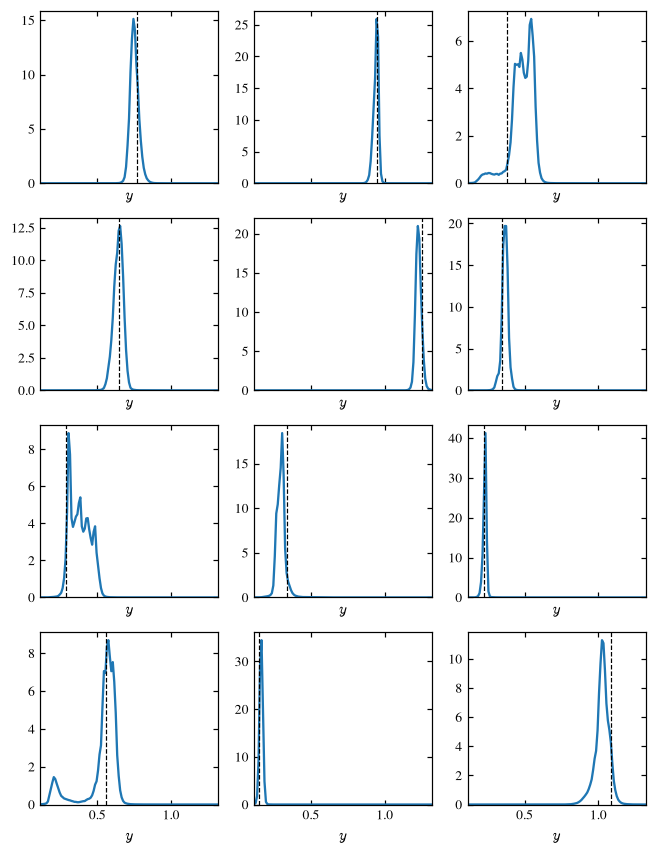

In [10]:
axes = plotting.plot_pdfs(
    grid, pdfs, y_true=z_test, n_objects=12, random_state=SEED
)

## Point estimates

Many analyses need a single number per galaxy. `predict` reduces each
density to a point estimate (by default its mode, `"mode"`), and
`metrics.grid_point_estimates` computes the same from densities that are
already in hand, without running the model again.

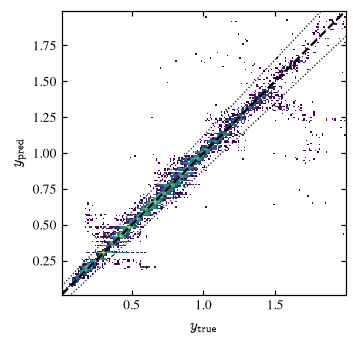

In [11]:
z_mode = metrics.grid_point_estimates(grid, pdfs)["mode"]

ax = plotting.plot_actual_vs_predicted(z_test, z_mode, outlier_lines=True)

Each point in the figure is a galaxy, colored by the number of galaxies that
share its place (on a log scale). The dotted lines, which
`outlier_lines=True` adds, mark the outlier cut of the Data Challenge,
$|z_\mathrm{pred} - z_\mathrm{true}| > 0.06\,(1+z_\mathrm{true})$. Most
galaxies sit well inside it, and the outliers come from color degeneracies,
where a galaxy at one redshift looks like one at another.

## Scoring the PDFs

`metrics.summarize` scores densities with the metrics of the Data Challenge.
These are the **CDE loss**, which scores whole PDFs (lower is better); the
**PIT** (probability integral transform) statistics, which test calibration
(i.e., whether the PDFs are as wide as they should be); and the **point**
metrics of the mode, which are the bias, the scatter and the outlier
fraction.

By default, the point metrics measure plain residuals,
$z_\mathrm{pred} - z_\mathrm{true}$. Since photometric redshift errors grow
with $1 + z$, the Data Challenge divided each residual by
$1 + z_\mathrm{true}$, and `scale="1+y"` asks for that convention.

In [12]:
table = metrics.summarize(z_test, grid, pdfs, label="TabPFN-3.5", scale="1+y")
table.T

,0
model,TabPFN-3.5
point_estimate,mode
scale,1+y
n,10000
bias,0.000025
sigma_mad,0.014316
sigma_iqr,0.01433
outlier_rate,0.0638
outlier_threshold,0.06
outlier_rate_015,0.0179


`plotting.diagnostic_panel` shows the same quantities in one figure. Its
panels show the point estimates against the truth; their residuals, as a
running median with its 68% band; the PIT quantiles against those of a
uniform distribution (which lie on the diagonal if the PDFs are calibrated);
and the stacked PDFs against the true redshift distribution $n(z)$. As
before, `scale="1+y"` uses the photo-$z$ convention for the residuals and the
outlier lines.

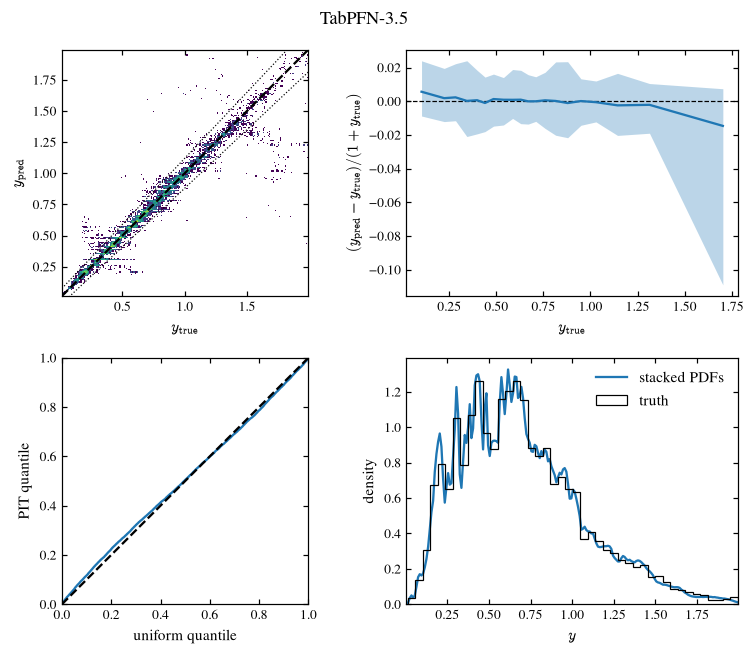

In [13]:
fig = plotting.diagnostic_panel(
    z_test, grid, pdfs, label="TabPFN-3.5", scale="1+y"
)

## Credible intervals

`predict_quantiles` returns quantiles of the distribution of each galaxy.
Since they are computed from the answer of the model itself rather than from
a grid, they are exact. Here we ask for the median and a 68% interval and
check how often the true redshift falls inside it, which for calibrated PDFs
should be 68% of the time.

In [14]:
q = model.predict_quantiles(X_test, [0.16, 0.5, 0.84])
inside = (q[:, 0] <= z_test) & (z_test <= q[:, 2])
print(
    f"True redshift inside the 68% interval for {inside.mean():.1%} of galaxies"
)

True redshift inside the 68% interval for 67.8% of galaxies


## Another model

Since every model has the same interface, trying another one takes a single
line. TabICL is small, BSD-licensed and fast on a CPU, which makes it the one
to use on a laptop. We run it on the same galaxies and compare the two
models.

We ask for 4 ensemble members instead of the default 8. With this many rows,
caching the context for 8 members briefly needs about 14 GB of GPU memory,
which is more than the T4 on Colab has to spare, while 4 members need about
7 GB.

In [15]:
tabicl = lazy.LazyModel("tabicl", n_estimators=4, random_state=SEED)
tabicl.fit(X_train, z_train)
pdfs_tabicl = tabicl.predict_proba(X_test, grid)

pd.concat(
    [
        table,
        metrics.summarize(
            z_test, grid, pdfs_tabicl, label="TabICL", scale="1+y"
        ),
    ]
).set_index("model").T

model,TabPFN-3.5,TabICL
point_estimate,mode,mode
scale,1+y,1+y
n,10000,10000
bias,0.000025,-0.000181
sigma_mad,0.014316,0.01527
sigma_iqr,0.01433,0.015246
outlier_rate,0.0638,0.0635
outlier_threshold,0.06,0.06
outlier_rate_015,0.0179,0.0183
median_abs_error,0.009664,0.010315


On most galaxies, the two models agree closely, and they differ where the
answer is uncertain. We therefore compare their PDFs for six of the hardest
galaxies, picked at random from the 5% whose TabPFN 68% interval is the
widest.

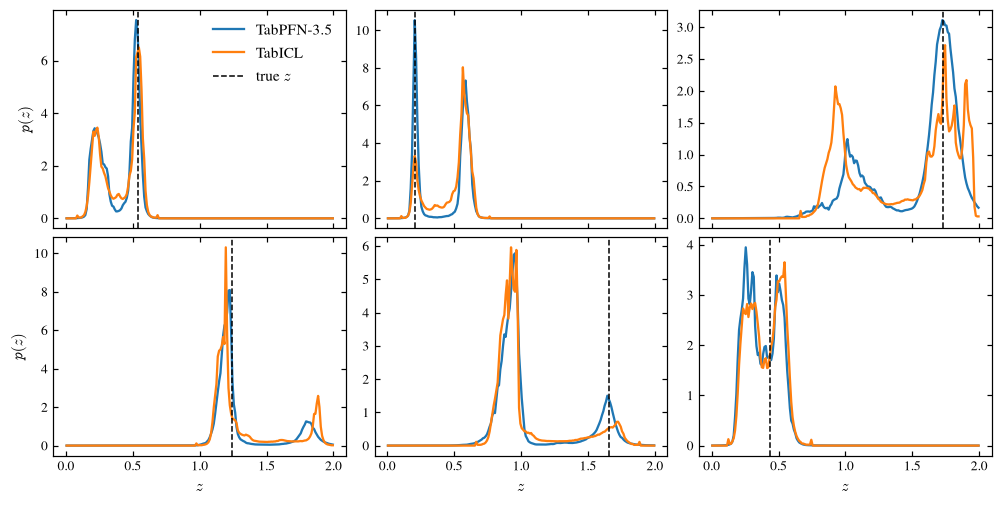

In [16]:
width = q[:, 2] - q[:, 0]
hardest = np.flatnonzero(width > np.quantile(width, 0.95))
idx = rng.choice(hardest, size=6, replace=False)

fig, axes = plt.subplots(
    2, 3, figsize=(9, 4.5), sharex=True, layout="constrained"
)
for ax, i in zip(axes.flat, idx):
    ax.plot(grid.centers, pdfs[i], label="TabPFN-3.5")
    ax.plot(grid.centers, pdfs_tabicl[i], label="TabICL")
    ax.axvline(z_test[i], color="k", ls="--", lw=1, label="true $z$")
for ax in axes[-1]:
    ax.set_xlabel("$z$")
for ax in axes[:, 0]:
    ax.set_ylabel("$p(z)$")
axes[0, 0].legend()

## Beyond redshifts

Nothing above depends on the target being a redshift. For any other
continuous target, we pass our own features and values to `fit` and our own
grid to `predict_proba` (for example,
`lazy.Grid.from_edges(np.linspace(0, 10, 201))`), or no grid at all. The
point metrics and plots then measure plain residuals,
$y_\mathrm{pred} - y_\mathrm{true}$, in the units of the target, since
`scale="1+y"` and `outlier_lines=True` were only for the photo-$z$
convention.

For the next steps, we suggest the following pages:

- [Supported models](https://lazy-tfm.readthedocs.io/en/latest/models/index.html):
  which model to choose, and what hardware it needs.
- [Backends](https://lazy-tfm.readthedocs.io/en/latest/guide/backends.html):
  ensembling, bagging, and large contexts.
- [Metrics and figures](https://lazy-tfm.readthedocs.io/en/latest/guide/metrics.html).